# Reproduce Steeghs-Turchina et al. (2025) Simulation 1

This notebook reproduces the first resting-state five-region simulation from the Steeghs-Turchina et al. model using `diaxcondel`.

It builds the reference five-region connectome, converts distances to lagged VAR coefficients through the inverse-GEV delay kernel, simulates resting activity with white noise, and plots the resulting time series, lag kernels, power spectra, and coherence.

Run from the repository root, or directly from `scripts/`. Plotting requires the optional visualization stack, e.g. `poetry install --with viz`.

In [1]:
import os
import sys
import tempfile
from pathlib import Path

ROOT = Path.cwd()
if not (ROOT / "src" / "diaxcondel").exists():
    ROOT = ROOT.parent
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "diaxcondel-mplconfig"))
sys.path.insert(0, str(ROOT / "src"))

In [2]:
import warnings

import matplotlib.pyplot as plt
import numpy as np

from diaxcondel.connectome.atlases.manual import (
    steeghs_2025_distances,
    steeghs_2025_regions,
    steeghs_2025_weights,
)
from diaxcondel.kernels.gev import GEVDiameter
from diaxcondel.kernels.invgev import InvGEVKernel
from diaxcondel.model.build import build_lag_tensor, build_linear_var
from diaxcondel.model.params import SimulationParams
from diaxcondel.simulate.engine import simulate
from diaxcondel.simulate.noise import get_noise_fn
from diaxcondel.spectral.analytical import analytical_psd
from diaxcondel.spectral.coherence import pairwise_coherence
from diaxcondel.spectral.empirical import welch_psd
from diaxcondel.viz import plot_coherence, plot_lag_kernels, plot_signal

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
warnings.simplefilter("default")

Matplotlib is building the font cache; this may take a moment.


## 1. Reference connectome and simulation parameters

The original proof-of-concept model uses five broad regions: frontal lobe (`FL`), parietal lobe (`PL`), occipital lobe (`OL`), temporal lobe (`TL`), and thalamus (`T`). Distances are streamline lengths in cm; weights are the tuned resting-state coupling matrix from the paper.

In [3]:
regions = steeghs_2025_regions()
distances = steeghs_2025_distances()
weights = steeghs_2025_weights()

params = SimulationParams(
    sample_rate_hz=1000,
    sim_seconds=10.0,
    burnin_seconds=1.0,
    n_lags=300,
)

diameter = GEVDiameter(mu=0.25, sigma=0.09, xi=-0.25)
kernel = InvGEVKernel(diameter=diameter, speed_factor=6.0)

distance_matrix = distances.matrix()
weight_matrix = weights.matrix()

print(regions.codes)
print(params)

('FL', 'PL', 'OL', 'TL', 'T')
sample_rate_hz=1000 sim_seconds=10.0 burnin_seconds=1.0 n_lags=300


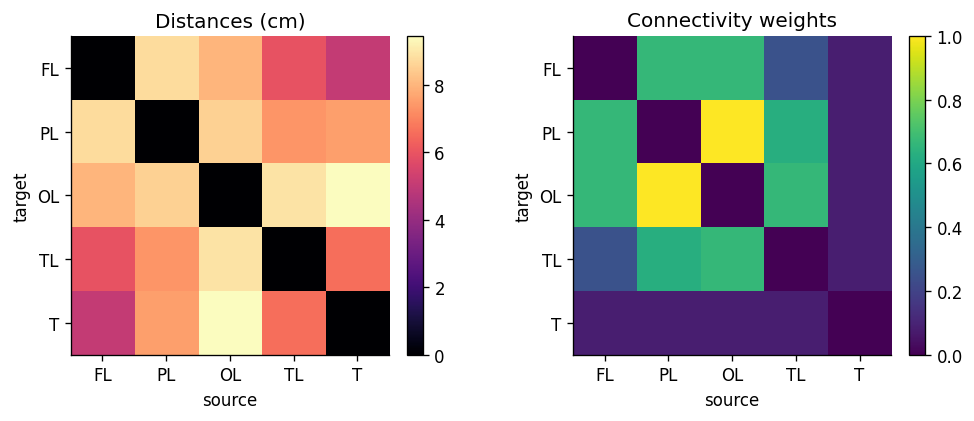

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(8.5, 3.4), constrained_layout=True)

im0 = axes[0].imshow(distance_matrix, cmap="magma")
axes[0].set_title("Distances (cm)")
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04)

im1 = axes[1].imshow(weight_matrix, cmap="viridis", vmin=0)
axes[1].set_title("Connectivity weights")
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

for ax in axes:
    ax.set_xticks(range(len(regions)))
    ax.set_yticks(range(len(regions)))
    ax.set_xticklabels(regions.codes)
    ax.set_yticklabels(regions.codes)
    ax.set_xlabel("source")
    ax.set_ylabel("target")

plt.show()

## 2. Build lagged VAR coefficients

`Phi[p, i, j]` is the lag-`p` contribution from source region `j` to target region `i`. Stationarity enforcement may shrink the effective coupling; the warning is informative and should not be hidden when reproducing the model.

In [5]:
phi_unshrunk = build_lag_tensor(distances, weights, kernel, params)
model = build_linear_var(distances, weights, kernel, params, enforce_stationarity=True)

print("unshrunk Phi shape:", phi_unshrunk.shape)
print("stationary Phi shape:", model.phi.shape)
print("total unshrunk coupling:", float(phi_unshrunk.sum()))
print("total stationary coupling:", float(model.phi.sum()))

unshrunk Phi shape: (300, 5, 5)
stationary Phi shape: (300, 5, 5)
total unshrunk coupling: 8.396121754051356
total stationary coupling: 4.015839006985326


/var/folders/j2/mbj9r8ps7730d3m6nysbkjkc0000gn/T/ipykernel_60628/759721634.py:2: UserWarning: shrank phi 7 times to reach stationarity (effective coupling reduced by factor 0.4783); consider reducing connectivity weights or speed_factor
  model = build_linear_var(distances, weights, kernel, params, enforce_stationarity=True)


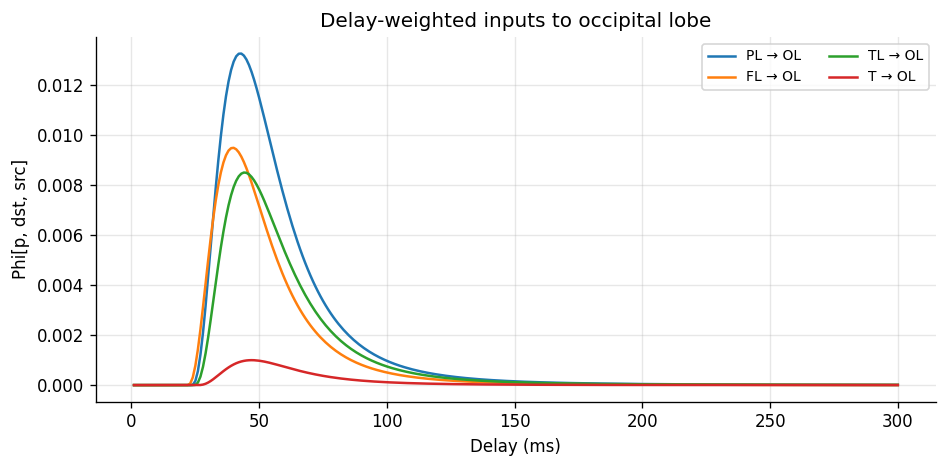

In [6]:
plot_lag_kernels(
    model.phi,
    regions,
    dt_s=params.dt_s,
    pairs=[("PL", "OL"), ("FL", "OL"), ("TL", "OL"), ("T", "OL")],
    title="Delay-weighted inputs to occipital lobe",
)
plt.show()

## 3. Simulate resting activity

Simulation 1 is resting-state: no external stimulus, white stochastic input, and post-burn-in analysis of the generated regional activity.

In [7]:
rng = np.random.default_rng(20260505)
result = simulate(
    model,
    params,
    get_noise_fn("white"),
    rng=rng,
    regions=regions,
)

print("signal shape:", result.signal.shape)
print("sample rate:", result.sample_rate_hz, "Hz")

signal shape: (10000, 5)
sample rate: 1000 Hz


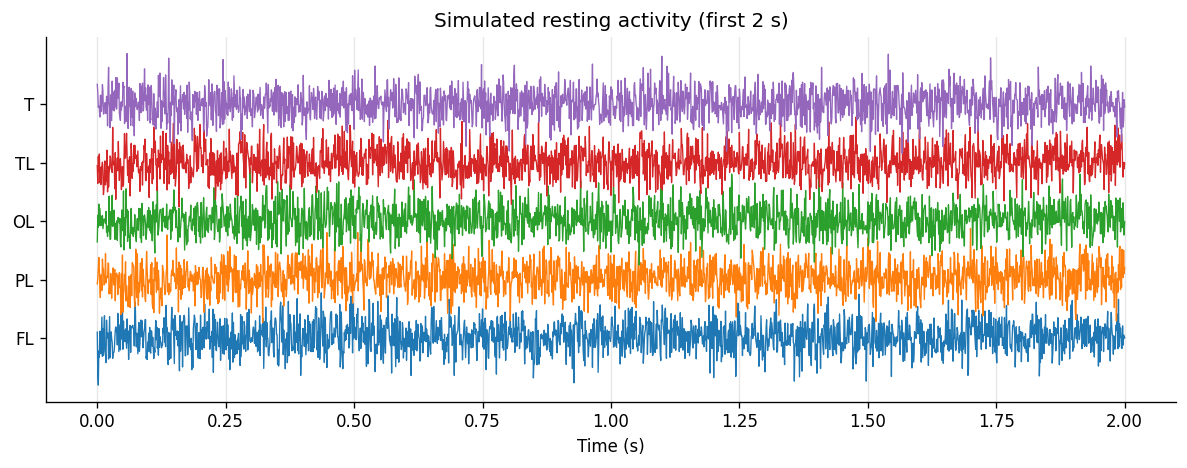

In [8]:
plot_signal(
    result.signal,
    regions,
    sample_rate_hz=params.sample_rate_hz,
    t_window_s=(0.0, 2.0),
    title="Simulated resting activity (first 2 s)",
)
plt.show()

## 4. Power spectra

The analytical PSD is deterministic for the fitted linear VAR. The empirical Welch PSD is a finite stochastic sample from the same model, so its band means will vary across random seeds and simulation lengths.

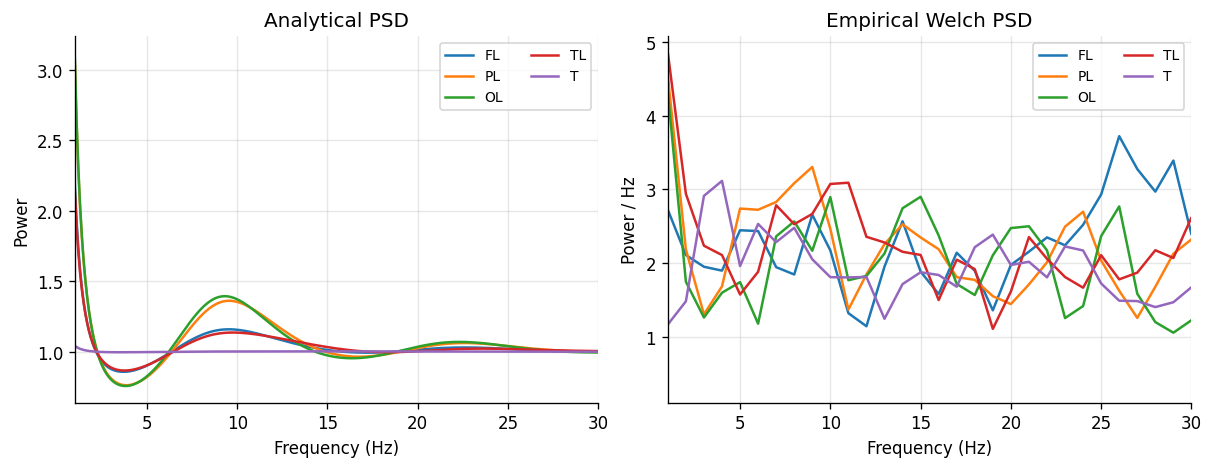

In [9]:
freqs_emp, psd_emp = welch_psd(result.signal, params.sample_rate_hz, segment_seconds=1.0, overlap=0.5)

freqs_ana = np.linspace(1.0, 50.0, 500)
psd_ana_full = analytical_psd(model, freqs_ana, params.dt_s)
psd_ana = np.diagonal(psd_ana_full, axis1=1, axis2=2)

fig, axes = plt.subplots(1, 2, figsize=(10, 3.8), constrained_layout=True)

for idx, code in enumerate(regions.codes):
    axes[0].plot(freqs_ana, psd_ana[:, idx], label=code)
axes[0].set_title("Analytical PSD")
axes[0].set_xlim(1, 30)
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Power")
axes[0].legend(ncol=2, fontsize="small")
axes[0].grid(alpha=0.3)

for idx, code in enumerate(regions.codes):
    axes[1].plot(freqs_emp, psd_emp[:, idx], label=code)
axes[1].set_title("Empirical Welch PSD")
axes[1].set_xlim(1, 30)
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Power / Hz")
axes[1].legend(ncol=2, fontsize="small")
axes[1].grid(alpha=0.3)

plt.show()

In [10]:
ol = regions.index("OL")
alpha = (freqs_ana >= 8.0) & (freqs_ana <= 13.0)
control = (freqs_ana >= 14.0) & (freqs_ana <= 20.0)
peak_idx = np.argmax(psd_ana[:, ol])

print("Occipital analytical PSD peak:", f"{freqs_ana[peak_idx]:.2f} Hz")
print("Occipital alpha-band mean:", f"{psd_ana[alpha, ol].mean():.4f}")
print("Occipital 14-20 Hz mean:", f"{psd_ana[control, ol].mean():.4f}")
print("alpha > control:", bool(psd_ana[alpha, ol].mean() > psd_ana[control, ol].mean()))

Occipital analytical PSD peak: 1.00 Hz
Occipital alpha-band mean: 1.2873
Occipital 14-20 Hz mean: 0.9813
alpha > control: True


## 5. Coherence

The paper reports that the simple macroscopic model reproduces several alpha-band features while also producing some imperfect low-frequency coherence behavior. This plot is useful for visually comparing the simulated pairwise coherence spectrum.

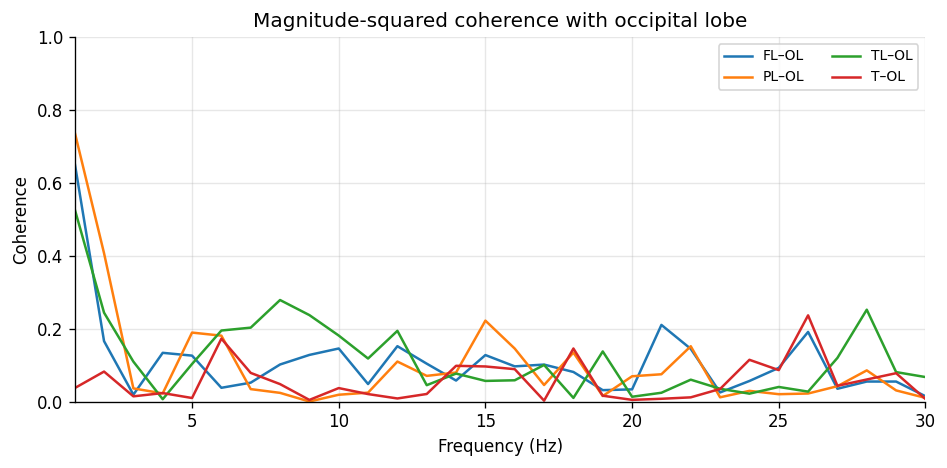

In [11]:
freqs_coh, coherence = pairwise_coherence(result.signal, params.sample_rate_hz, segment_seconds=1.0, overlap=0.5)

plot_coherence(
    freqs_coh,
    coherence,
    regions,
    pairs=[("FL", "OL"), ("PL", "OL"), ("TL", "OL"), ("T", "OL")],
    xlim=(1.0, 30.0),
    title="Magnitude-squared coherence with occipital lobe",
)
plt.show()